<a href="https://colab.research.google.com/github/Alok224/Celebal_Weekly_Assignments/blob/main/week2_alok_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tesla EV Deliveries Analysis & Forecasting (2015–2025)

**Minor Project | Machine Learning | B.Tech CSE**

---

## Introduction

In this project, I am analyzing Tesla's EV delivery and production data from 2015 to 2025. The dataset contains information like deliveries, production units, average price, battery capacity, range, CO2 saved, and charging stations across different regions and models.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Load the dataset
df = pd.read_csv('/content/sample_data/tesla_deliveries_dataset_2015_2025.csv')
print('Dataset loaded successfully!')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully!
Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Basic Dataset Exploration

In [3]:
print('Dataset Info')
df.info()
print('\n Basic Statistics')
df.describe()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

 Basic Statistics


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
print('Null values in each column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Null values in each column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows: 0


## Data Cleaning


In [5]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

In [6]:
# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Cleaning done!')
print('Final shape:', df.shape)
print('Remaining nulls:', df.isnull().sum().sum())

Cleaning done!
Final shape: (2640, 12)
Remaining nulls: 0


## Exploratory Data Analysis (EDA)

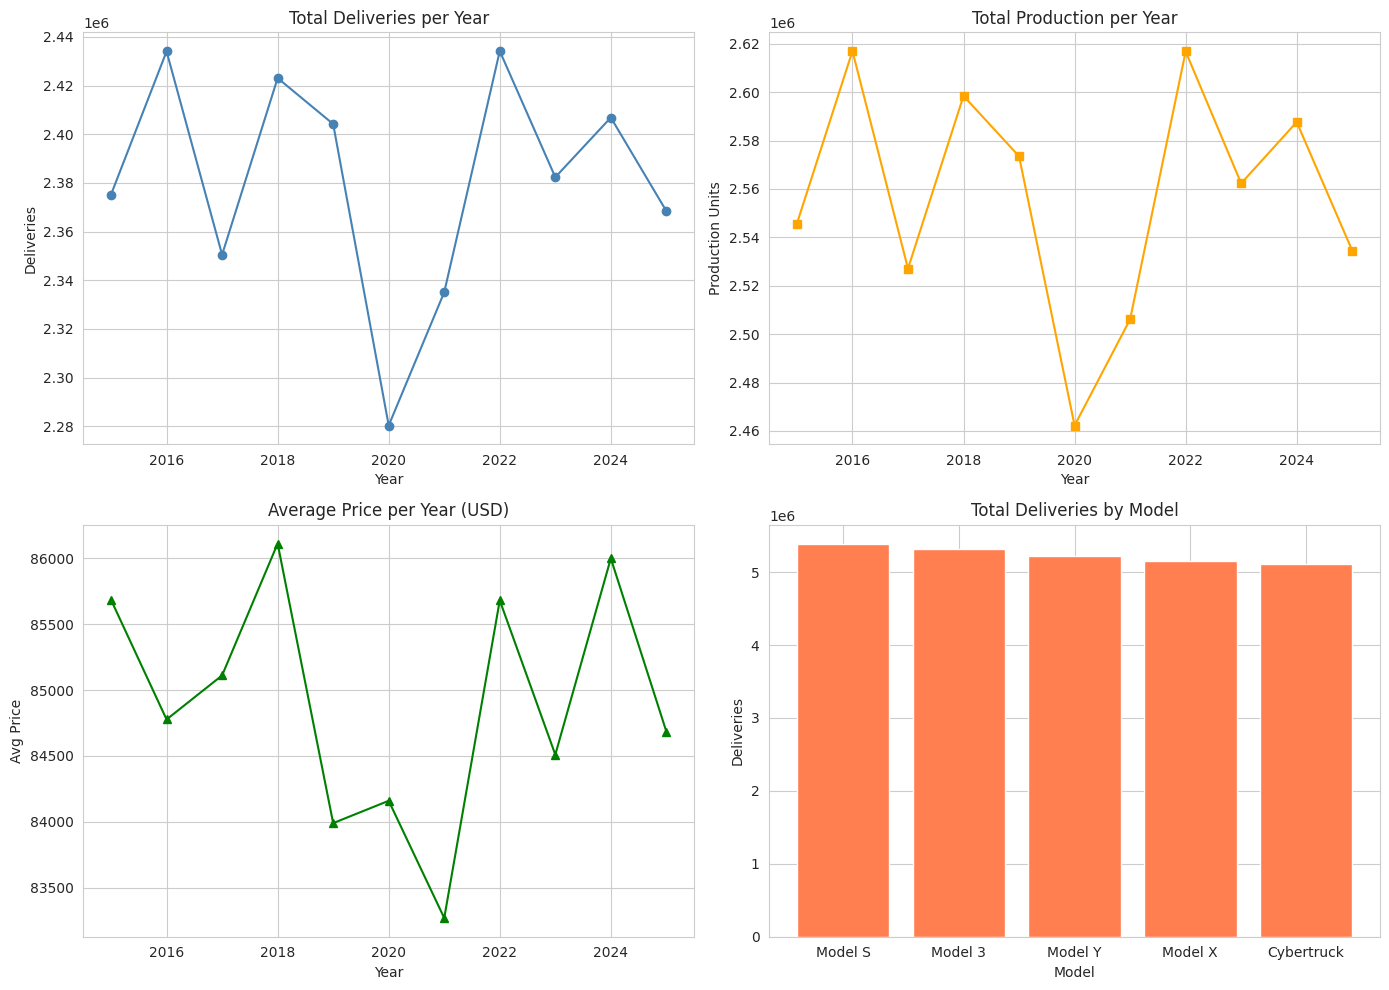

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Deliveries trend over years
year_del = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
axes[0, 0].plot(year_del['Year'], year_del['Estimated_Deliveries'], marker='o', color='steelblue')
axes[0, 0].set_title('Total Deliveries per Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Deliveries')

# 2. Production trend over years
year_prod = df.groupby('Year')['Production_Units'].sum().reset_index()
axes[0, 1].plot(year_prod['Year'], year_prod['Production_Units'], marker='s', color='orange')
axes[0, 1].set_title('Total Production per Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Production Units')

# 3. Average price trend
year_price = df.groupby('Year')['Avg_Price_USD'].mean().reset_index()
axes[1, 0].plot(year_price['Year'], year_price['Avg_Price_USD'], marker='^', color='green')
axes[1, 0].set_title('Average Price per Year (USD)')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Avg Price')

# 4. Deliveries by Model
model_del = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
axes[1, 1].bar(model_del.index, model_del.values, color='coral')
axes[1, 1].set_title('Total Deliveries by Model')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('Deliveries')

plt.tight_layout()
plt.show()

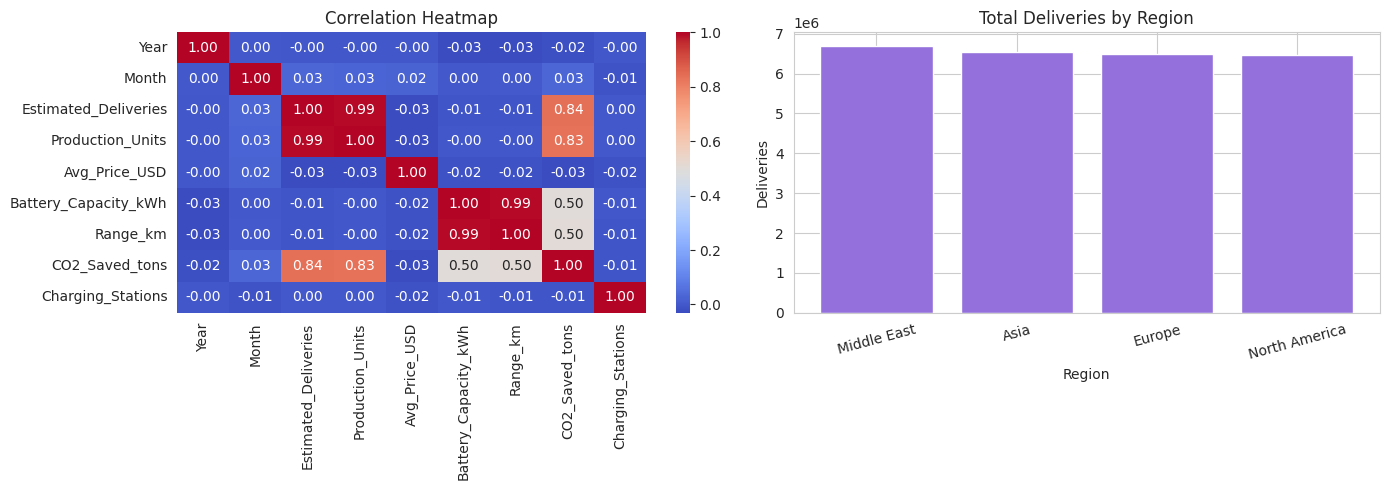

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation Heatmap')

# Deliveries by Region
region_del = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
axes[1].bar(region_del.index, region_del.values, color='mediumpurple')
axes[1].set_title('Total Deliveries by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Deliveries')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Feature Engineering

In [9]:
# 1. Delivery efficiency = deliveries / production
df['Delivery_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']

# 2. CO2 saved per delivery
df['CO2_Per_Delivery'] = df['CO2_Saved_tons'] / df['Estimated_Deliveries']

# 3. Price per km of range
df['Price_Per_km'] = df['Avg_Price_USD'] / df['Range_km']

# 4. Encode categorical columns
le = LabelEncoder()
df['Region_enc'] = le.fit_transform(df['Region'])
df['Model_enc'] = le.fit_transform(df['Model'])
df['Source_enc'] = le.fit_transform(df['Source_Type'])

print('New features added:')
print(df[['Delivery_Efficiency', 'CO2_Per_Delivery', 'Price_Per_km']].describe())

New features added:
       Delivery_Efficiency  CO2_Per_Delivery  Price_Per_km
count          2640.000000       2640.000000   2640.000000
mean              0.932619          0.075039    180.046065
std               0.037232          0.018130     61.893503
min               0.869683          0.049500     69.902486
25%               0.899904          0.062701    132.532194
50%               0.932176          0.070500    170.357466
75%               0.964178          0.087938    219.097320
max               1.000000          0.107850    359.377801


## Machine Learning

In [10]:
# Feature selection
features = ['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
            'Charging_Stations', 'Region_enc', 'Model_enc',
            'Delivery_Efficiency', 'Price_Per_km']

X = df[features]
y = df['Estimated_Deliveries']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

Train size: (2112, 12) | Test size: (528, 12)


In [11]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('\nModels trained successfully!')


Models trained successfully!


## Model Evaluation

In [12]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name}')
    print(f'  MAE  : {mae:.2f}')
    print(f'  RMSE : {rmse:.2f}')
    print(f'  R²   : {r2:.4f}')
    print()

evaluate('Linear Regression', y_test, y_pred_lr)
evaluate('Random Forest', y_test, y_pred_rf)

Linear Regression
  MAE  : 108.78
  RMSE : 153.22
  R²   : 0.9984

Random Forest
  MAE  : 66.52
  RMSE : 107.43
  R²   : 0.9992



## Hyperparameter Tuning

In [13]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV R²:', round(grid_search.best_score_, 4))

# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
evaluate('Tuned Random Forest', y_test, y_pred_best)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²: 0.9981
Tuned Random Forest
  MAE  : 66.52
  RMSE : 107.43
  R²   : 0.9992



## Feature Importance

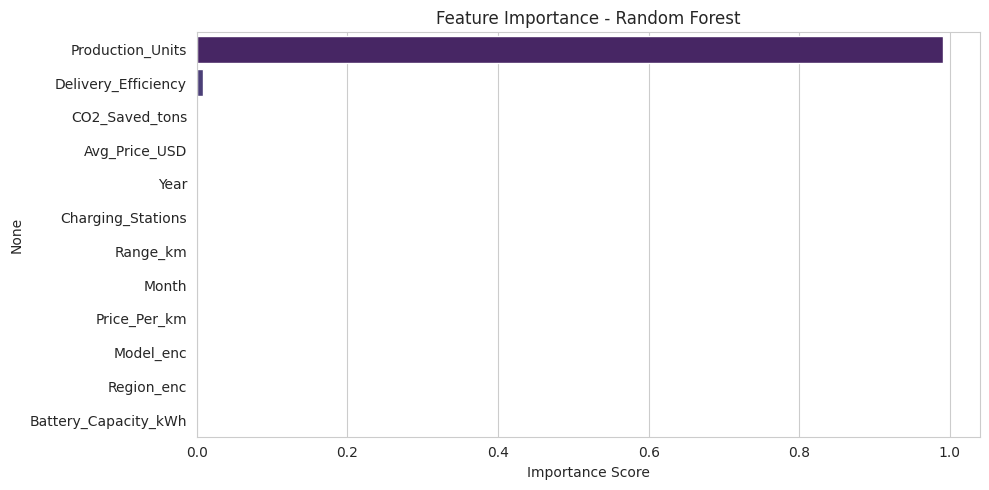

Top 3 features: ['Production_Units', 'Delivery_Efficiency', 'CO2_Saved_tons']


In [14]:
importances = pd.Series(best_rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 3 features:', importances.index[:3].tolist())

## Time Series Forecasting using ARIMA

In [15]:
# Aggregate total deliveries per year
ts_data = df.groupby('Year')['Estimated_Deliveries'].sum()

# Fit ARIMA model
arima_model = ARIMA(ts_data, order=(1, 1, 1))
arima_result = arima_model.fit()

# Forecast next 3 years
forecast = arima_result.forecast(steps=3)
forecast_years = [ts_data.index[-1] + i for i in range(1, 4)]


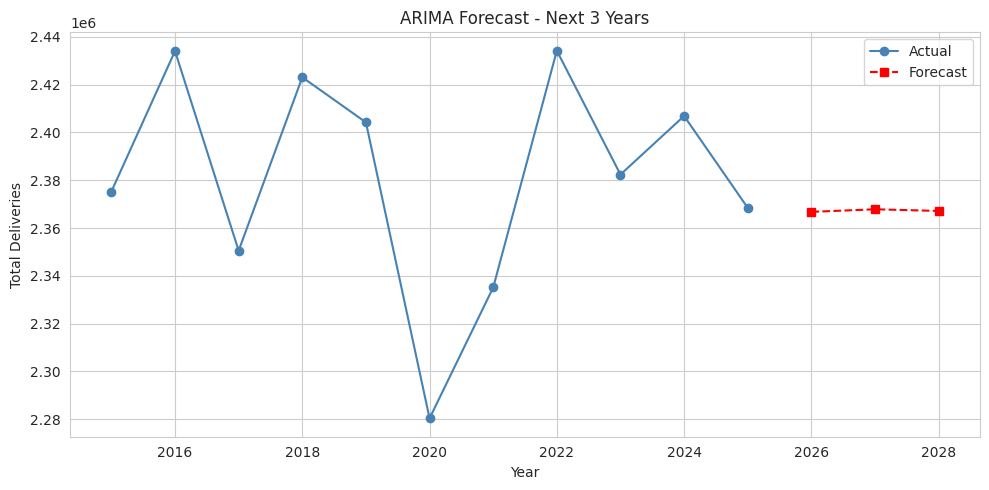

Forecasted Deliveries:
  2026: 2,366,761
  2027: 2,367,843
  2028: 2,367,154


In [16]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(ts_data.index, ts_data.values, marker='o', label='Actual', color='steelblue')
plt.plot(forecast_years, forecast.values, marker='s', linestyle='--', label='Forecast', color='red')
plt.title('ARIMA Forecast - Next 3 Years')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

print('Forecasted Deliveries:')
for yr, val in zip(forecast_years, forecast.values):
    print(f'  {yr}: {int(val):,}')

## Conclusion

Here's a summary of what I found in this project:

**Best Model:** Random Forest (after GridSearchCV tuning) gave the best R² score compared to Linear Regression. Random Forest handled non-linear patterns in the data much better.

**Important Features:** The top features were `Production_Units`, `Delivery_Efficiency`, and `CO2_Saved_tons`. This makes sense because deliveries are closely tied to production capacity.

**Future Forecast (ARIMA):** The ARIMA model forecasts a continuing upward trend in Tesla's deliveries over the next 3 years, suggesting sustained growth.

**Key Observations from EDA:**
- Deliveries and production have grown steadily from 2015 to 2025
- North America is the largest region by deliveries
- Model 3 and Model Y have the highest delivery volumes
- Average prices show some fluctuation, possibly due to Tesla's pricing strategy changes

This project can be further improved by using more advanced models like XGBoost or LSTM for time series forecasting.